#TensorFlowのインポート

In [ ]:
import tensorflow as tf
tf.__version__

'2.6.0'

#その他のライブラリのインポート

In [ ]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

#画像の大きさの設定

In [ ]:
IMAGE_SIZE = 28

#MNISTの読み込み（数字の読み込み）

In [ ]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


#読み込んだ数字の表示
train_images[0]の数字を変えると別の画像が見られます．

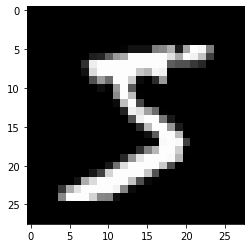

In [ ]:
plt.imshow(train_images[0], cmap='gray')

#画像変換
0～255の画像を-1～1に変換しています．

In [ ]:
train_images = train_images.reshape(train_images.shape[0], IMAGE_SIZE, IMAGE_SIZE, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # －1～＋1のデータとする

#TensorFlow用データへの変換

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

#生成器（generator）のモデルの定義
---



In [ ]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(IMAGE_SIZE//4*IMAGE_SIZE//4*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((IMAGE_SIZE//4, IMAGE_SIZE//4, 256)))
    assert model.output_shape == (None, IMAGE_SIZE//4, IMAGE_SIZE//4, 256)  # Noneはバッチ・サイズ
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, IMAGE_SIZE//4, IMAGE_SIZE//4, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, IMAGE_SIZE//2, IMAGE_SIZE//2, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, IMAGE_SIZE, IMAGE_SIZE, 1)

    return model

#モデルの生成と初期状態での画像の生成

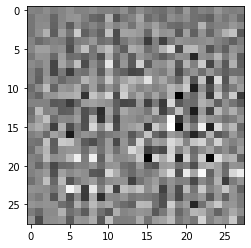

In [ ]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

#モデルの表示

In [ ]:
generator.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 12544)             1254400   
_________________________________________________________________
batch_normalization (BatchNo (None, 12544)             50176     
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 12544)             0         
_________________________________________________________________
reshape (Reshape)            (None, 7, 7, 256)         0         
_________________________________________________________________
conv2d_transpose (Conv2DTran (None, 7, 7, 128)         819200    
_________________________________________________________________
batch_normalization_1 (Batch (None, 7, 7, 128)         512       
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 7, 7, 128)         0

#分別器（discriminator）のモデルの定義

In [ ]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[IMAGE_SIZE, IMAGE_SIZE, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

#モデルの生成と初期状態で生成した画像の分類

In [ ]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

tf.Tensor([[-0.00300638]], shape=(1, 1), dtype=float32)


#モデルの表示

In [ ]:
discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 14, 14, 64)        1664      
_________________________________________________________________
leaky_re_lu_3 (LeakyReLU)    (None, 14, 14, 64)        0         
_________________________________________________________________
dropout (Dropout)            (None, 14, 14, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 7, 7, 128)         204928    
_________________________________________________________________
leaky_re_lu_4 (LeakyReLU)    (None, 7, 7, 128)         0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 7, 7, 128)         0         
_________________________________________________________________
flatten (Flatten)            (None, 6272)             

#損失関数の設定

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

#分別器（discriminator）の損失関数の設定

In [ ]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

#生成器（generator）の損失関数の設定

In [ ]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

#生成器と分別器のオプティマイザの設定

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

#Googleドライブのマウント
必要ない場合は実行しなくてもOKです．

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#再開用ファイルの設定
2行目のコメント・アウトを外すとGoogleドライブに保存されます．その際はGoogleドライブをマウントしておく必要があります．

In [ ]:
checkpoint_dir = './training_checkpoints'
# checkpoint_dir = '/content/drive/MyDrive/training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

#変数の設定

In [ ]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

#学習の設定

In [ ]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

#繰り返し学習の設定
チェックポイントの保存にはかなりの容量が必要となりますので注意してください

In [ ]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)

#    if (epoch + 1) % 15 == 0:# チェックポイントを有効にするためにはコメント・アウトを外す
#      checkpoint.save(file_prefix = checkpoint_prefix)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

#画像を保存するための設定

In [ ]:
def generate_and_save_images(model, epoch, test_input):
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

#学習開始
1行目のコメント・アウトを外すと途中から再開できます．

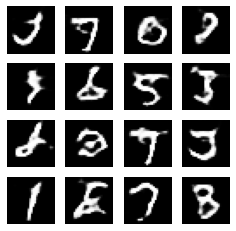

In [ ]:
# checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))
train(train_dataset, EPOCHS)

#GIFアニメーション作成用処理
#ライブラリのインストール

In [ ]:
! pip install imageio

#ライブラリのインポート

In [ ]:
import imageio

#GIFアニメーションの作成

In [ ]:
anim_file = 'dcgan.gif'
# anim_file = '/content/drive/MyDrive/dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames = glob.glob('image*.png')
  filenames = sorted(filenames)
  for filename in filenames:
    image = imageio.imread(filename)
    writer.append_data(image)
  image = imageio.imread(filename)
  writer.append_data(image)

#GIFアニメーションの表示用処理
#関連プログラムのインストール

In [ ]:
! pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-40hs72xl
  Running command git clone -q https://github.com/tensorflow/docs /tmp/pip-req-build-40hs72xl
  Created wheel for tensorflow-docs: filename=tensorflow_docs-0.0.0.dev0-py3-none-any.whl size=157855 sha256=ddf05e2191650841d1ebf672be844940876e2d51e13d52e1e66cb6f4b83c15f5
  Stored in directory: /tmp/pip-ephem-wheel-cache-xhlooaon/wheels/cc/c4/d8/5341e93b6376c5c929c49469fce21155eb69cef1a4da4ce32c
Successfully built tensorflow-docs


#ライブラリのインポート

In [ ]:
import tensorflow_docs.vis.embed as embed

#GIFアニメーションの表示


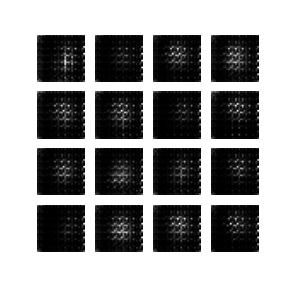

In [ ]:
embed.embed_file(anim_file)